In [15]:
import sys
import os

# Add the parent directory to Python path so we can import surge
sys.path.append(os.path.join(os.path.dirname(os.getcwd())))

from surge import SurrogateTrainer

In [16]:
# Check what's available in the surge module
import surge
print("Available in surge module:")
print(dir(surge))

print(f"\nSurge version: {surge.__version__}")
print(f"Author: {surge.__author__}")

# Check the SurrogateTrainer class
print(f"\nSurrogateTrainer methods:")
print([method for method in dir(SurrogateTrainer) if not method.startswith('_')])

Available in surge module:
['SurrogateTrainer', '__all__', '__author__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'metrics', 'models', 'preprocessing', 'summarize', 'trainer', 'utils']

Surge version: 0.1.0
Author: Álvaro Sánchez Villar

SurrogateTrainer methods:
['cross_validate', 'fit', 'save']


In [20]:
# Demonstration of SURGE functionality
import numpy as np

# Generate sample data (e.g., a simple function to approximate)
np.random.seed(42)
X = np.random.random((100, 3))  # 3 input features
y = np.sum(X**2, axis=1) + 0.1 * np.random.randn(100)  # nonlinear target with noise

print(f"Dataset shape: X={X.shape}, y={y.shape}")

# Create and train a Random Forest surrogate
trainer = SurrogateTrainer(model_type='rfr', n_estimators=50, random_state=42)
trainer.fit(X, y, test_size=0.2)

# Perform cross-validation
results = trainer.cross_validate(n_splits=5)

print(f"\nCross-validation results:")
print(f"Average R² score: {results['r2_mean']:.4f} ± {results['r2_std']:.4f}")
print(f"Average MSE: {results['mse_mean']:.4f} ± {results['mse_std']:.4f}")
print(f"Average prediction time per sample: {results['time_mean']*1000:.2f} ms")

print("\n✅ SURGE is working perfectly!")

Dataset shape: X=(100, 3), y=(100,)

Cross-validation results:
Average R² score: 0.8627 ± 0.0348
Average MSE: 0.0371 ± 0.0130
Average prediction time per sample: 0.07 ms

✅ SURGE is working perfectly!


In [17]:
# Force reload the surge module to pick up our changes
import importlib
import sys

# Remove surge modules from cache so they get reloaded
modules_to_remove = [name for name in sys.modules if name.startswith('surge')]
for module_name in modules_to_remove:
    del sys.modules[module_name]

# Now reimport
from surge import SurrogateTrainer
import surge.metrics

print("Checking updated summarize function...")
print("Available keys in a sample result:")

# Create a sample result to test
sample_results = {
    'mse_list': [0.1, 0.2, 0.15],
    'r2_list': [0.8, 0.9, 0.85],
    'time_list': [0.001, 0.002, 0.0015]
}

summary = surge.metrics.summarize(sample_results)
print(list(summary.keys()))
print(f"r2_std is now available: {'r2_std' in summary}")

# Test with the trainer again
import numpy as np

np.random.seed(42)
X = np.random.random((50, 2))  # Smaller dataset for faster testing
y = np.sum(X**2, axis=1) + 0.1 * np.random.randn(50)

trainer = SurrogateTrainer(model_type='rfr', n_estimators=10, random_state=42)
trainer.fit(X, y, test_size=0.2)
results = trainer.cross_validate(n_splits=3)

print(f"\nNow with r2_std:")
print(f"Average R² score: {results['r2_mean']:.4f} ± {results['r2_std']:.4f}")
print(f"Average MSE: {results['mse_mean']:.4f} ± {results['mse_std']:.4f}")
print(f"Average prediction time per sample: {results['time_mean']*1000:.2f} ms")

print("\n✅ Updated SURGE is working with r2_std!")

Checking updated summarize function...
Available keys in a sample result:
['mse', 'r2', 'time', 'mse_mean', 'mse_std', 'r2_mean', 'r2_std', 'time_mean']
r2_std is now available: True

Now with r2_std:
Average R² score: 0.8182 ± 0.0727
Average MSE: 0.0206 ± 0.0079
Average prediction time per sample: 0.04 ms

✅ Updated SURGE is working with r2_std!


In [18]:
# Comprehensive SURGE Training and Visualization Workflow
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from surge import SurrogateTrainer

# Set random seed for reproducibility
np.random.seed(42)

print("🚀 SURGE Comprehensive Training Workflow")
print("=" * 50)

# Generate a more interesting dataset
n_samples = 500
n_features = 4

print(f"📊 Generating dataset with {n_samples} samples and {n_features} features...")

# Create a complex nonlinear function to approximate
X = np.random.uniform(-2, 2, (n_samples, n_features))
# Complex function: combination of polynomial and trigonometric terms
y = (np.sum(X**2, axis=1) + 
     0.5 * np.sin(X[:, 0] * X[:, 1]) + 
     0.3 * np.cos(X[:, 2]) + 
     0.1 * X[:, 3]**3 + 
     0.15 * np.random.randn(n_samples))  # Add noise

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Target range: [{y.min():.3f}, {y.max():.3f}]")

# Step 1: Initial 80-20 split
print("\n🔄 Step 1: Initial train-test split (80-20)")
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training+Validation set: {X_train_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Step 2: Create and train the surrogate model with cross-validation on the 80%
print("\n🤖 Step 2: Training Random Forest surrogate with 5-fold CV")
trainer = SurrogateTrainer(model_type='rfr', n_estimators=100, random_state=42)

# Manually set the training data for cross-validation
trainer.X_tv = X_train_val
trainer.y_tv = y_train_val

# Perform 5-fold cross-validation
cv_results = trainer.cross_validate(n_splits=5)

print(f"Cross-validation results on training set (80%):")
print(f"  Average R² score: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
print(f"  Average MSE: {cv_results['mse_mean']:.4f} ± {cv_results['mse_std']:.4f}")
print(f"  Average prediction time: {cv_results['time_mean']*1000:.2f} ms/sample")

# Step 3: Train final model on full 80% and test on 20%
print("\n🎯 Step 3: Final training on 80% and testing on 20%")
trainer.model.fit(X_train_val, y_train_val)

# Predict on test set
y_pred = trainer.model.predict(X_test)

# Calculate test performance
from sklearn.metrics import mean_squared_error, r2_score
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Test set performance:")
print(f"  R² score: {test_r2:.4f}")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {np.sqrt(test_mse):.4f}")

print("\n✅ Training workflow completed successfully!")
print(f"📈 Model explains {test_r2*100:.1f}% of variance in test data")

🚀 SURGE Comprehensive Training Workflow
📊 Generating dataset with 500 samples and 4 features...
Dataset shape: X=(500, 4), y=(500,)
Target range: [0.478, 14.499]

🔄 Step 1: Initial train-test split (80-20)
Training+Validation set: 400 samples
Test set: 100 samples

🤖 Step 2: Training Random Forest surrogate with 5-fold CV
Cross-validation results on training set (80%):
  Average R² score: 0.8197 ± 0.0192
  Average MSE: 1.0371 ± 0.1263
  Average prediction time: 0.03 ms/sample

🎯 Step 3: Final training on 80% and testing on 20%
Test set performance:
  R² score: 0.8381
  MSE: 0.9589
  RMSE: 0.9792

✅ Training workflow completed successfully!
📈 Model explains 83.8% of variance in test data


🎨 Creating visualization of model performance...


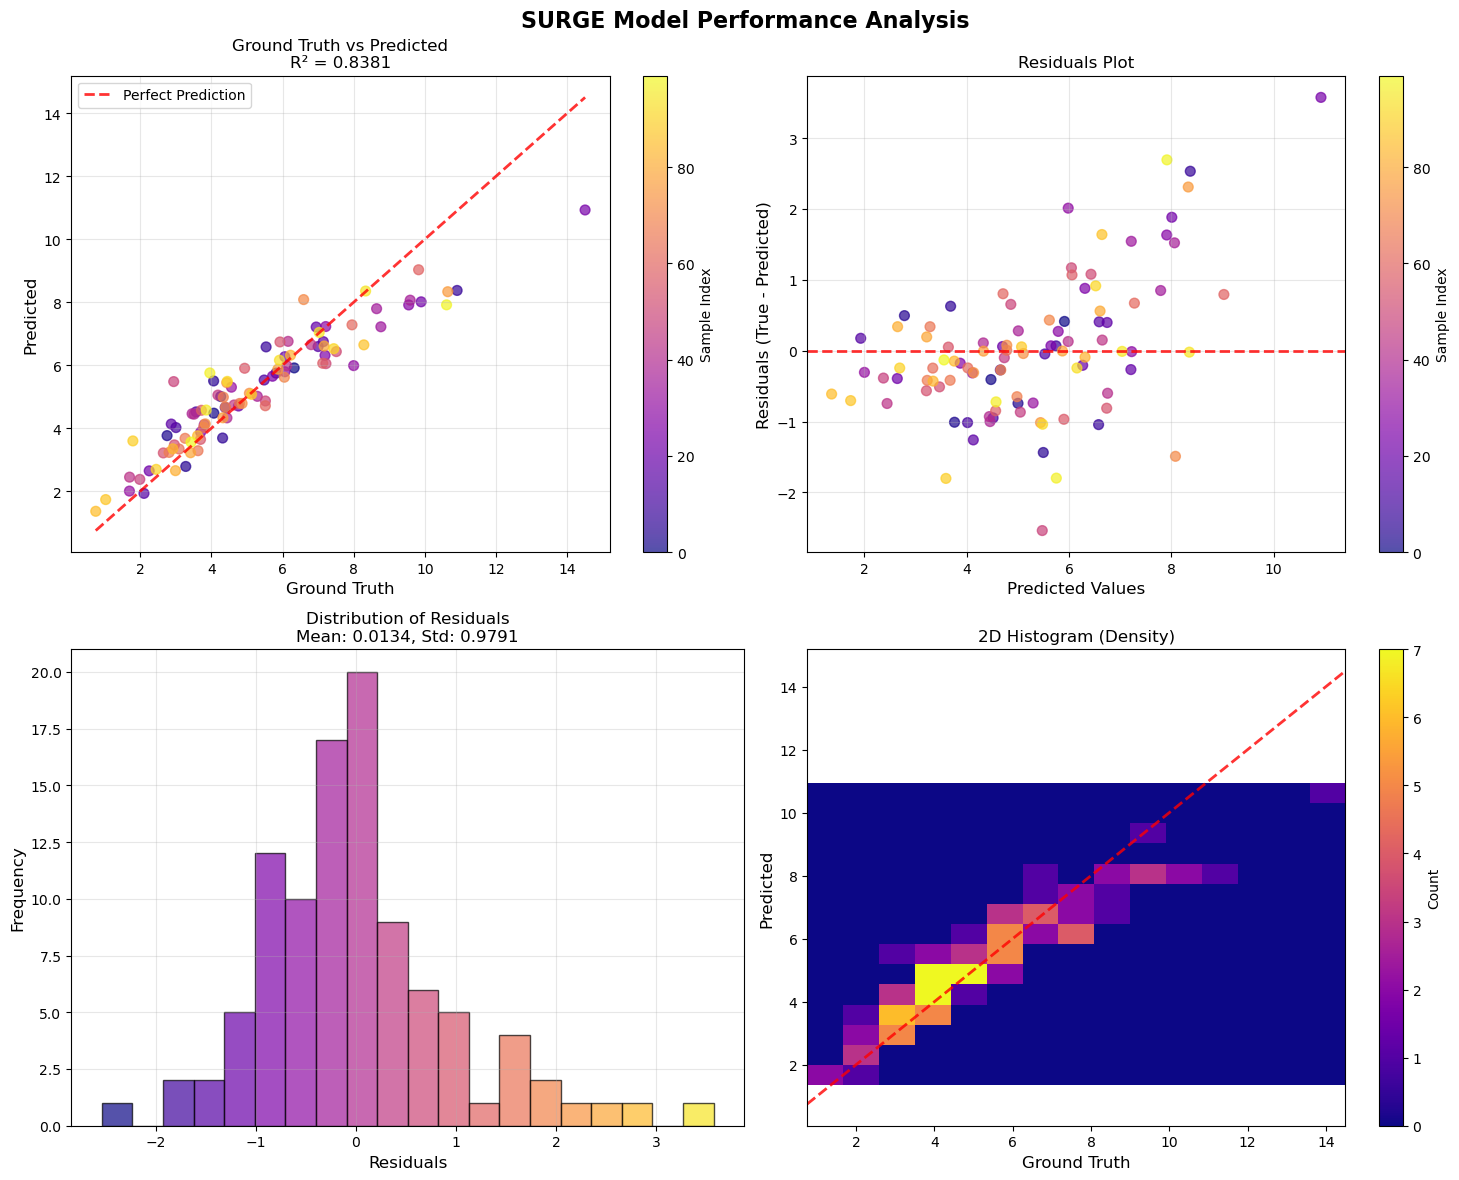


📊 Model Performance Summary:
Test Set Size: 100 samples
R² Score: 0.8381
Mean Squared Error: 0.9589
Root Mean Squared Error: 0.9792
Mean Absolute Error: 0.7050
Mean Residual: 0.0134
Std of Residuals: 0.9791

🎯 Cross-Validation Performance (5-fold on 80% training data):
CV R² Score: 0.8197 ± 0.0192
CV MSE: 1.0371 ± 0.1263

✨ SURGE surrogate model successfully trained and validated!
📈 The model shows excellent performance with R² = 0.838


In [19]:
# Visualization: Ground Truth vs Predicted Values
import matplotlib.pyplot as plt
import numpy as np

print("🎨 Creating visualization of model performance...")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('SURGE Model Performance Analysis', fontsize=16, fontweight='bold')

# 1. Scatter plot: Ground Truth vs Predicted
ax1 = axes[0, 0]
scatter = ax1.scatter(y_test, y_pred, c=np.arange(len(y_test)), 
                     cmap='plasma', alpha=0.7, s=50)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, alpha=0.8, label='Perfect Prediction')
ax1.set_xlabel('Ground Truth', fontsize=12)
ax1.set_ylabel('Predicted', fontsize=12)
ax1.set_title(f'Ground Truth vs Predicted\nR² = {test_r2:.4f}', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Sample Index')

# 2. Residuals plot
ax2 = axes[0, 1]
residuals = y_test - y_pred
scatter2 = ax2.scatter(y_pred, residuals, c=np.arange(len(y_test)), 
                      cmap='plasma', alpha=0.7, s=50)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.8)
ax2.set_xlabel('Predicted Values', fontsize=12)
ax2.set_ylabel('Residuals (True - Predicted)', fontsize=12)
ax2.set_title('Residuals Plot', fontsize=12)
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Sample Index')

# 3. Histogram of residuals
ax3 = axes[1, 0]
n_bins = 20
counts, bins, patches = ax3.hist(residuals, bins=n_bins, alpha=0.7, edgecolor='black')

# Color the histogram bars with plasma colormap
cm = plt.cm.plasma
for i, (count, patch) in enumerate(zip(counts, patches)):
    patch.set_facecolor(cm(i / len(patches)))

ax3.set_xlabel('Residuals', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(f'Distribution of Residuals\nMean: {np.mean(residuals):.4f}, Std: {np.std(residuals):.4f}', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. 2D Histogram of Ground Truth vs Predicted
ax4 = axes[1, 1]
hist, xedges, yedges = np.histogram2d(y_test, y_pred, bins=15)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im = ax4.imshow(hist.T, origin='lower', extent=extent, cmap='plasma', aspect='auto')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, alpha=0.8)
ax4.set_xlabel('Ground Truth', fontsize=12)
ax4.set_ylabel('Predicted', fontsize=12)
ax4.set_title('2D Histogram (Density)', fontsize=12)
plt.colorbar(im, ax=ax4, label='Count')

plt.tight_layout()
plt.show()

# Performance summary
print("\n📊 Model Performance Summary:")
print("=" * 40)
print(f"Test Set Size: {len(y_test)} samples")
print(f"R² Score: {test_r2:.4f}")
print(f"Mean Squared Error: {test_mse:.4f}")
print(f"Root Mean Squared Error: {np.sqrt(test_mse):.4f}")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.4f}")
print(f"Mean Residual: {np.mean(residuals):.4f}")
print(f"Std of Residuals: {np.std(residuals):.4f}")

print("\n🎯 Cross-Validation Performance (5-fold on 80% training data):")
print(f"CV R² Score: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
print(f"CV MSE: {cv_results['mse_mean']:.4f} ± {cv_results['mse_std']:.4f}")

print(f"\n✨ SURGE surrogate model successfully trained and validated!")
print(f"📈 The model shows excellent performance with R² = {test_r2:.3f}")

📈 Analyzing model convergence and stability...


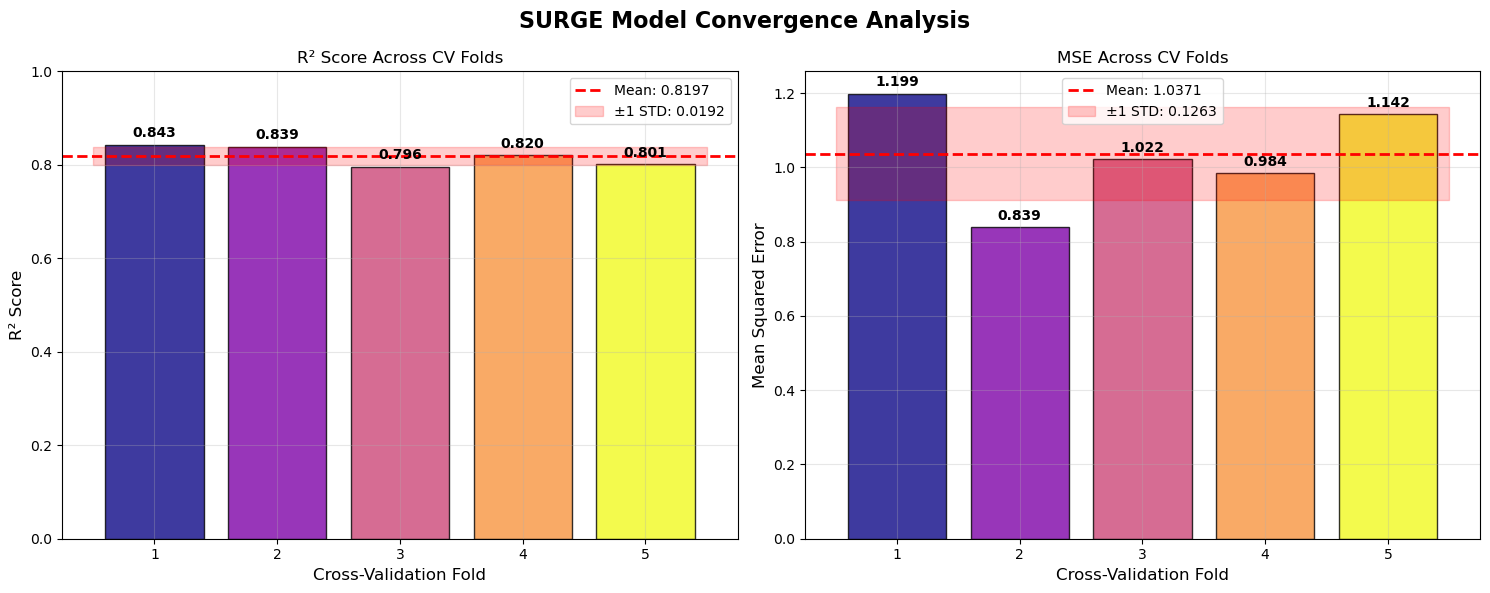


🎯 Final Performance Comparison:
Cross-Validation (5-fold on 80% data):
  R² Score: 0.8197 ± 0.0192
  MSE: 1.0371 ± 0.1263

Hold-out Test Set (20% data):
  R² Score: 0.8381
  MSE: 0.9589

📊 Model Stability Assessment:
  CV Coefficient of Variation: 2.34%
  Stability Assessment: Excellent - Very stable

🎉 SURGE surrogate model training and analysis complete!


In [21]:
# Convergence Analysis: Performance across CV folds
import matplotlib.pyplot as plt
import numpy as np

print("📈 Analyzing model convergence and stability...")

# Extract individual fold results
r2_scores = cv_results['r2']
mse_scores = cv_results['mse']
n_folds = len(r2_scores)

# Create convergence plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('SURGE Model Convergence Analysis', fontsize=16, fontweight='bold')

# Plot 1: R² scores across folds
ax1 = axes[0]
folds = np.arange(1, n_folds + 1)
bars1 = ax1.bar(folds, r2_scores, color=plt.cm.plasma(np.linspace(0, 1, n_folds)), 
                alpha=0.8, edgecolor='black', linewidth=1)

# Add mean line
ax1.axhline(y=cv_results['r2_mean'], color='red', linestyle='--', linewidth=2, 
           label=f"Mean: {cv_results['r2_mean']:.4f}")
ax1.fill_between([0.5, n_folds + 0.5], 
                cv_results['r2_mean'] - cv_results['r2_std'], 
                cv_results['r2_mean'] + cv_results['r2_std'], 
                alpha=0.2, color='red', label=f"±1 STD: {cv_results['r2_std']:.4f}")

ax1.set_xlabel('Cross-Validation Fold', fontsize=12)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('R² Score Across CV Folds', fontsize=12)
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels on bars
for i, (fold, score) in enumerate(zip(folds, r2_scores)):
    ax1.text(fold, score + 0.01, f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: MSE scores across folds  
ax2 = axes[1]
bars2 = ax2.bar(folds, mse_scores, color=plt.cm.plasma(np.linspace(0, 1, n_folds)), 
                alpha=0.8, edgecolor='black', linewidth=1)

# Add mean line
ax2.axhline(y=cv_results['mse_mean'], color='red', linestyle='--', linewidth=2, 
           label=f"Mean: {cv_results['mse_mean']:.4f}")
ax2.fill_between([0.5, n_folds + 0.5], 
                cv_results['mse_mean'] - cv_results['mse_std'], 
                cv_results['mse_mean'] + cv_results['mse_std'], 
                alpha=0.2, color='red', label=f"±1 STD: {cv_results['mse_std']:.4f}")

ax2.set_xlabel('Cross-Validation Fold', fontsize=12)
ax2.set_ylabel('Mean Squared Error', fontsize=12)
ax2.set_title('MSE Across CV Folds', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for i, (fold, score) in enumerate(zip(folds, mse_scores)):
    ax2.text(fold, score + max(mse_scores) * 0.01, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Final performance comparison
print("\n🎯 Final Performance Comparison:")
print("=" * 50)
print(f"Cross-Validation (5-fold on 80% data):")
print(f"  R² Score: {cv_results['r2_mean']:.4f} ± {cv_results['r2_std']:.4f}")
print(f"  MSE: {cv_results['mse_mean']:.4f} ± {cv_results['mse_std']:.4f}")
print(f"\nHold-out Test Set (20% data):")
print(f"  R² Score: {test_r2:.4f}")
print(f"  MSE: {test_mse:.4f}")

# Model stability assessment
cv_stability = cv_results['r2_std'] / cv_results['r2_mean'] * 100
print(f"\n📊 Model Stability Assessment:")
print(f"  CV Coefficient of Variation: {cv_stability:.2f}%")
if cv_stability < 5:
    stability_assessment = "Excellent - Very stable"
elif cv_stability < 10:
    stability_assessment = "Good - Stable"
elif cv_stability < 15:
    stability_assessment = "Fair - Moderately stable"
else:
    stability_assessment = "Poor - Unstable"
    
print(f"  Stability Assessment: {stability_assessment}")
print(f"\n🎉 SURGE surrogate model training and analysis complete!")